In [11]:
import pandas as pd

columns = [
    "buying",
    "maint",
    "doors",
    "persons",
    "lug_boot",
    "safety",
    "class"
]

df = pd.read_csv(
    "car_evaluation.csv",
    header=None,
    names=columns
)

print(df.head())

  buying  maint doors persons lug_boot safety  class
0  vhigh  vhigh     2       2    small    low  unacc
1  vhigh  vhigh     2       2    small    med  unacc
2  vhigh  vhigh     2       2    small   high  unacc
3  vhigh  vhigh     2       2      med    low  unacc
4  vhigh  vhigh     2       2      med    med  unacc


In [12]:
df.shape

(1728, 7)

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1728 entries, 0 to 1727
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   buying    1728 non-null   str  
 1   maint     1728 non-null   str  
 2   doors     1728 non-null   str  
 3   persons   1728 non-null   str  
 4   lug_boot  1728 non-null   str  
 5   safety    1728 non-null   str  
 6   class     1728 non-null   str  
dtypes: str(7)
memory usage: 133.5 KB


In [14]:
df.isnull().sum()

buying      0
maint       0
doors       0
persons     0
lug_boot    0
safety      0
class       0
dtype: int64

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df.describe()

,buying,maint,doors,persons,lug_boot,safety,class
count,1728,1728,1728,1728,1728,1728,1728
unique,4,4,4,3,3,3,4
top,vhigh,vhigh,2,2,small,low,unacc
freq,432,432,432,576,576,576,1210


In [19]:
df["class"].unique()

<ArrowStringArray>
['unacc', 'acc', 'vgood', 'good']
Length: 4, dtype: str

In [20]:
df["class"].value_counts()

class
unacc    1210
acc       384
good       69
vgood      65
Name: count, dtype: int64

In [21]:
df.columns

Index(['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class'], dtype='str')

In [ ]:
## So in our data there is features name that are categorical in nature so we need to convert them into numerical values.


---- Data Information ---
<class 'pandas.DataFrame'>
RangeIndex: 1728 entries, 0 to 1727
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   buying    1728 non-null   float64
 1   maint     1728 non-null   float64
 2   doors     1728 non-null   float64
 3   persons   1728 non-null   float64
 4   lug_boot  1728 non-null   float64
 5   safety    1728 non-null   float64
 6   class     1728 non-null   float64
dtypes: float64(7)
memory usage: 94.6 KB
None

----- Descriptive Summary-----
            buying        maint        doors      persons     lug_boot  \
count  1728.000000  1728.000000  1728.000000  1728.000000  1728.000000   
mean      1.500000     1.500000     1.500000     1.000000     1.000000   
std       1.118358     1.118358     1.118358     0.816733     0.816733   
min       0.000000     0.000000     0.000000     0.000000     0.000000   
25%       0.750000     0.750000     0.750000     0.000000     0.000000   
50%   

/var/folders/gg/fz86m7ms739bwnj9rd2yllkr0000gn/T/ipykernel_2565/1384726938.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="class", data = df_encoded, palette="viridis")


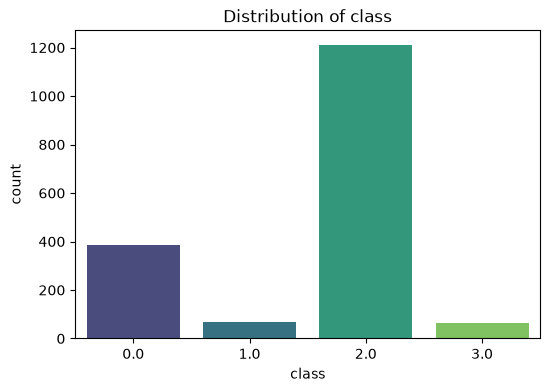

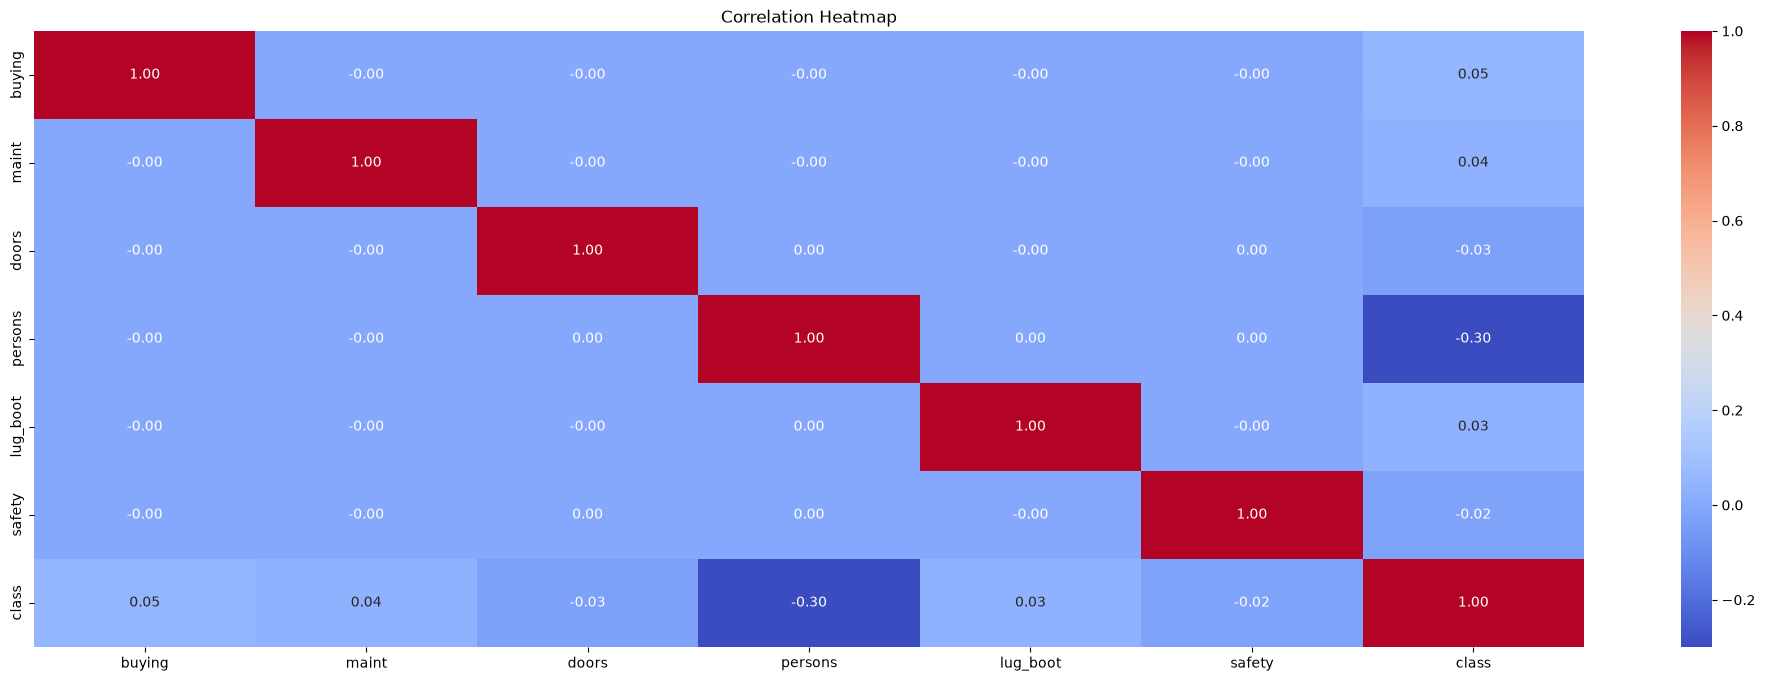

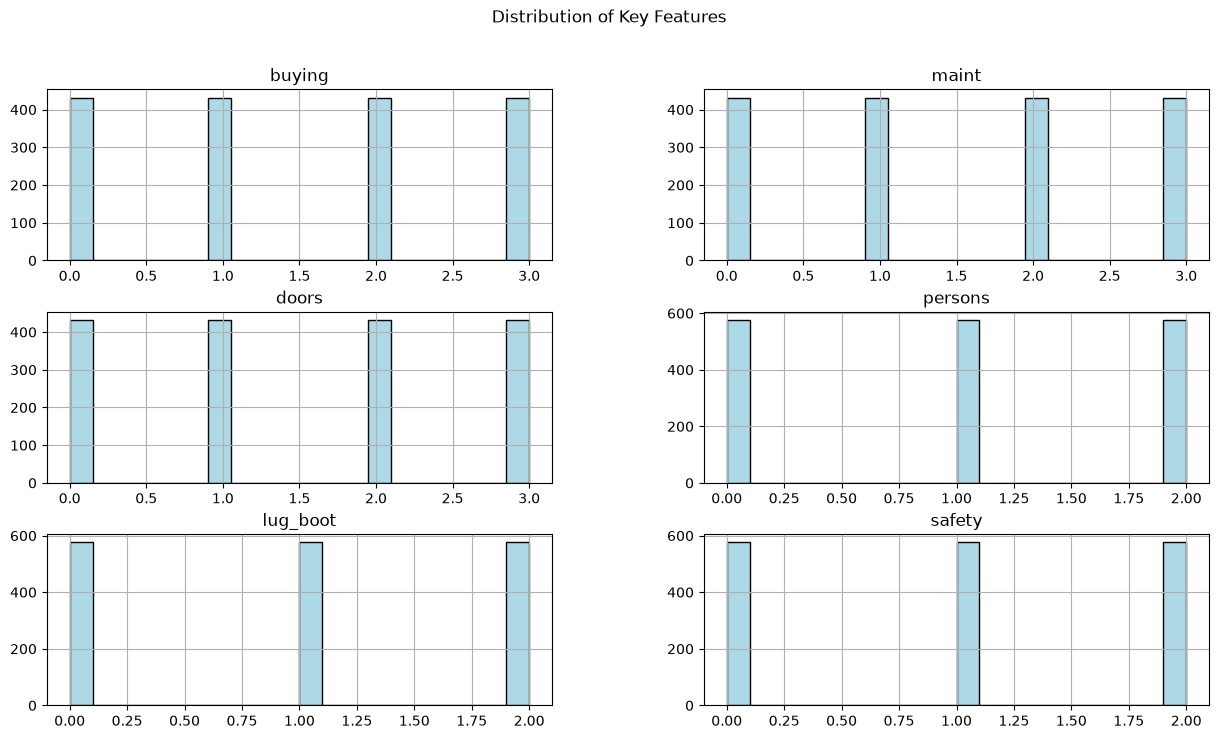

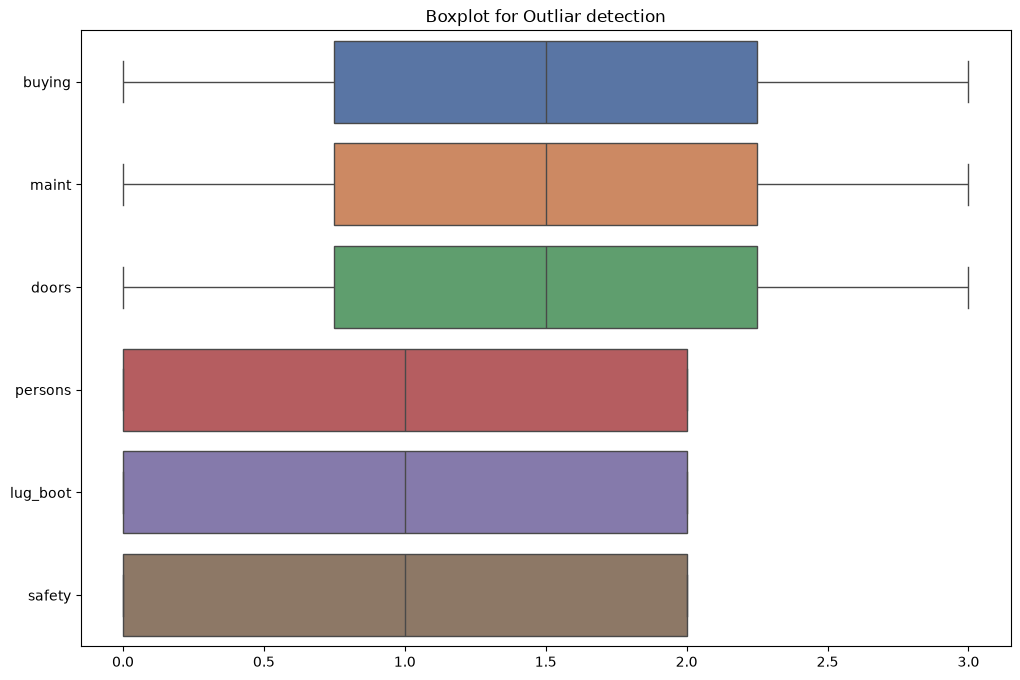

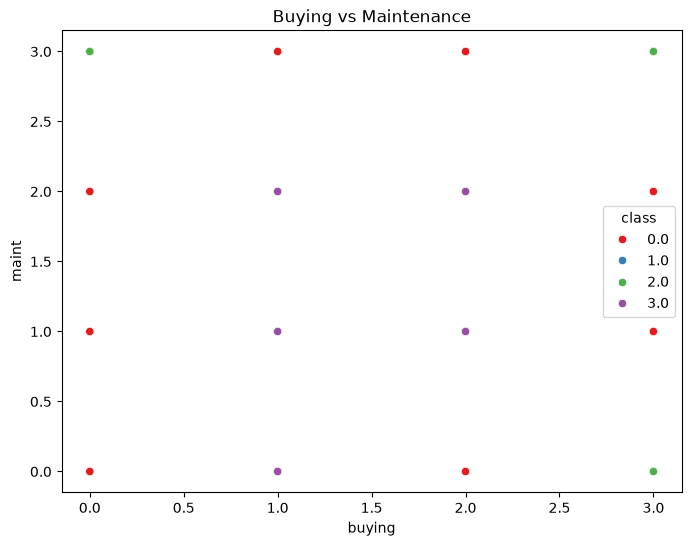

In [26]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder

df = pd.read_csv("car_evaluation.csv", header=None, names=columns)
encoder = OrdinalEncoder()

df_encoded = pd.DataFrame(
    encoder.fit_transform(df),
    columns=df.columns
)

df_encoded.head(2)

#1 Load and preprase data
X = df_encoded.drop("class", axis =1)
y = df_encoded["class"]

#2 Basic Inseption
print("---- Data Information ---")
print(df_encoded.info())
print("\n----- Descriptive Summary-----")
print(df_encoded.describe())

# Check the missing values
print("\n----- Missing Values -----")
print(df_encoded.isnull().sum())

## check the class balance
plt.figure(figsize=(6,4))
sns.countplot(x="class", data = df_encoded, palette="viridis")
plt.title("Distribution of class")
plt.show()


## Heatmap
## Highly correlated features can be removed to reduce the dimensionality of the data
# and to avoid multicollinearity issue in the model.
# (features might be redundant for a decission tree)
plt.figure(figsize=(25,8))
sns.heatmap(df_encoded.corr(), annot = True, cmap = "coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

# Distribution of key features
cols_to_plot =["buying", "maint", "doors", "persons", "lug_boot", "safety"]
df_encoded[cols_to_plot].hist(figsize=(15,8), bins =20, color = "LightBlue", edgecolor ="black")
plt.suptitle("Distribution of Key Features")
plt.show()

## Outliar Detection
plt.figure(figsize=(12,8))
sns.boxplot(data = df_encoded[cols_to_plot], orient ="h", palette = "deep")
plt.title("Boxplot for Outliar detection")
plt.show()

# Biveariate Analysis: mean radius vs mean parimeter
plt.figure(figsize=(8,6))
sns.scatterplot(x= "buying", y= "maint", hue="class", data = df_encoded, palette = "Set1")
plt.title("Buying vs Maintenance")
plt.show()

------ Unpruned Model ------
Train Accuracy : 1.00
Test Accuracy  : 0.97

------ Pruned Model ------
Train Accuracy : 0.78
Test Accuracy  : 0.76


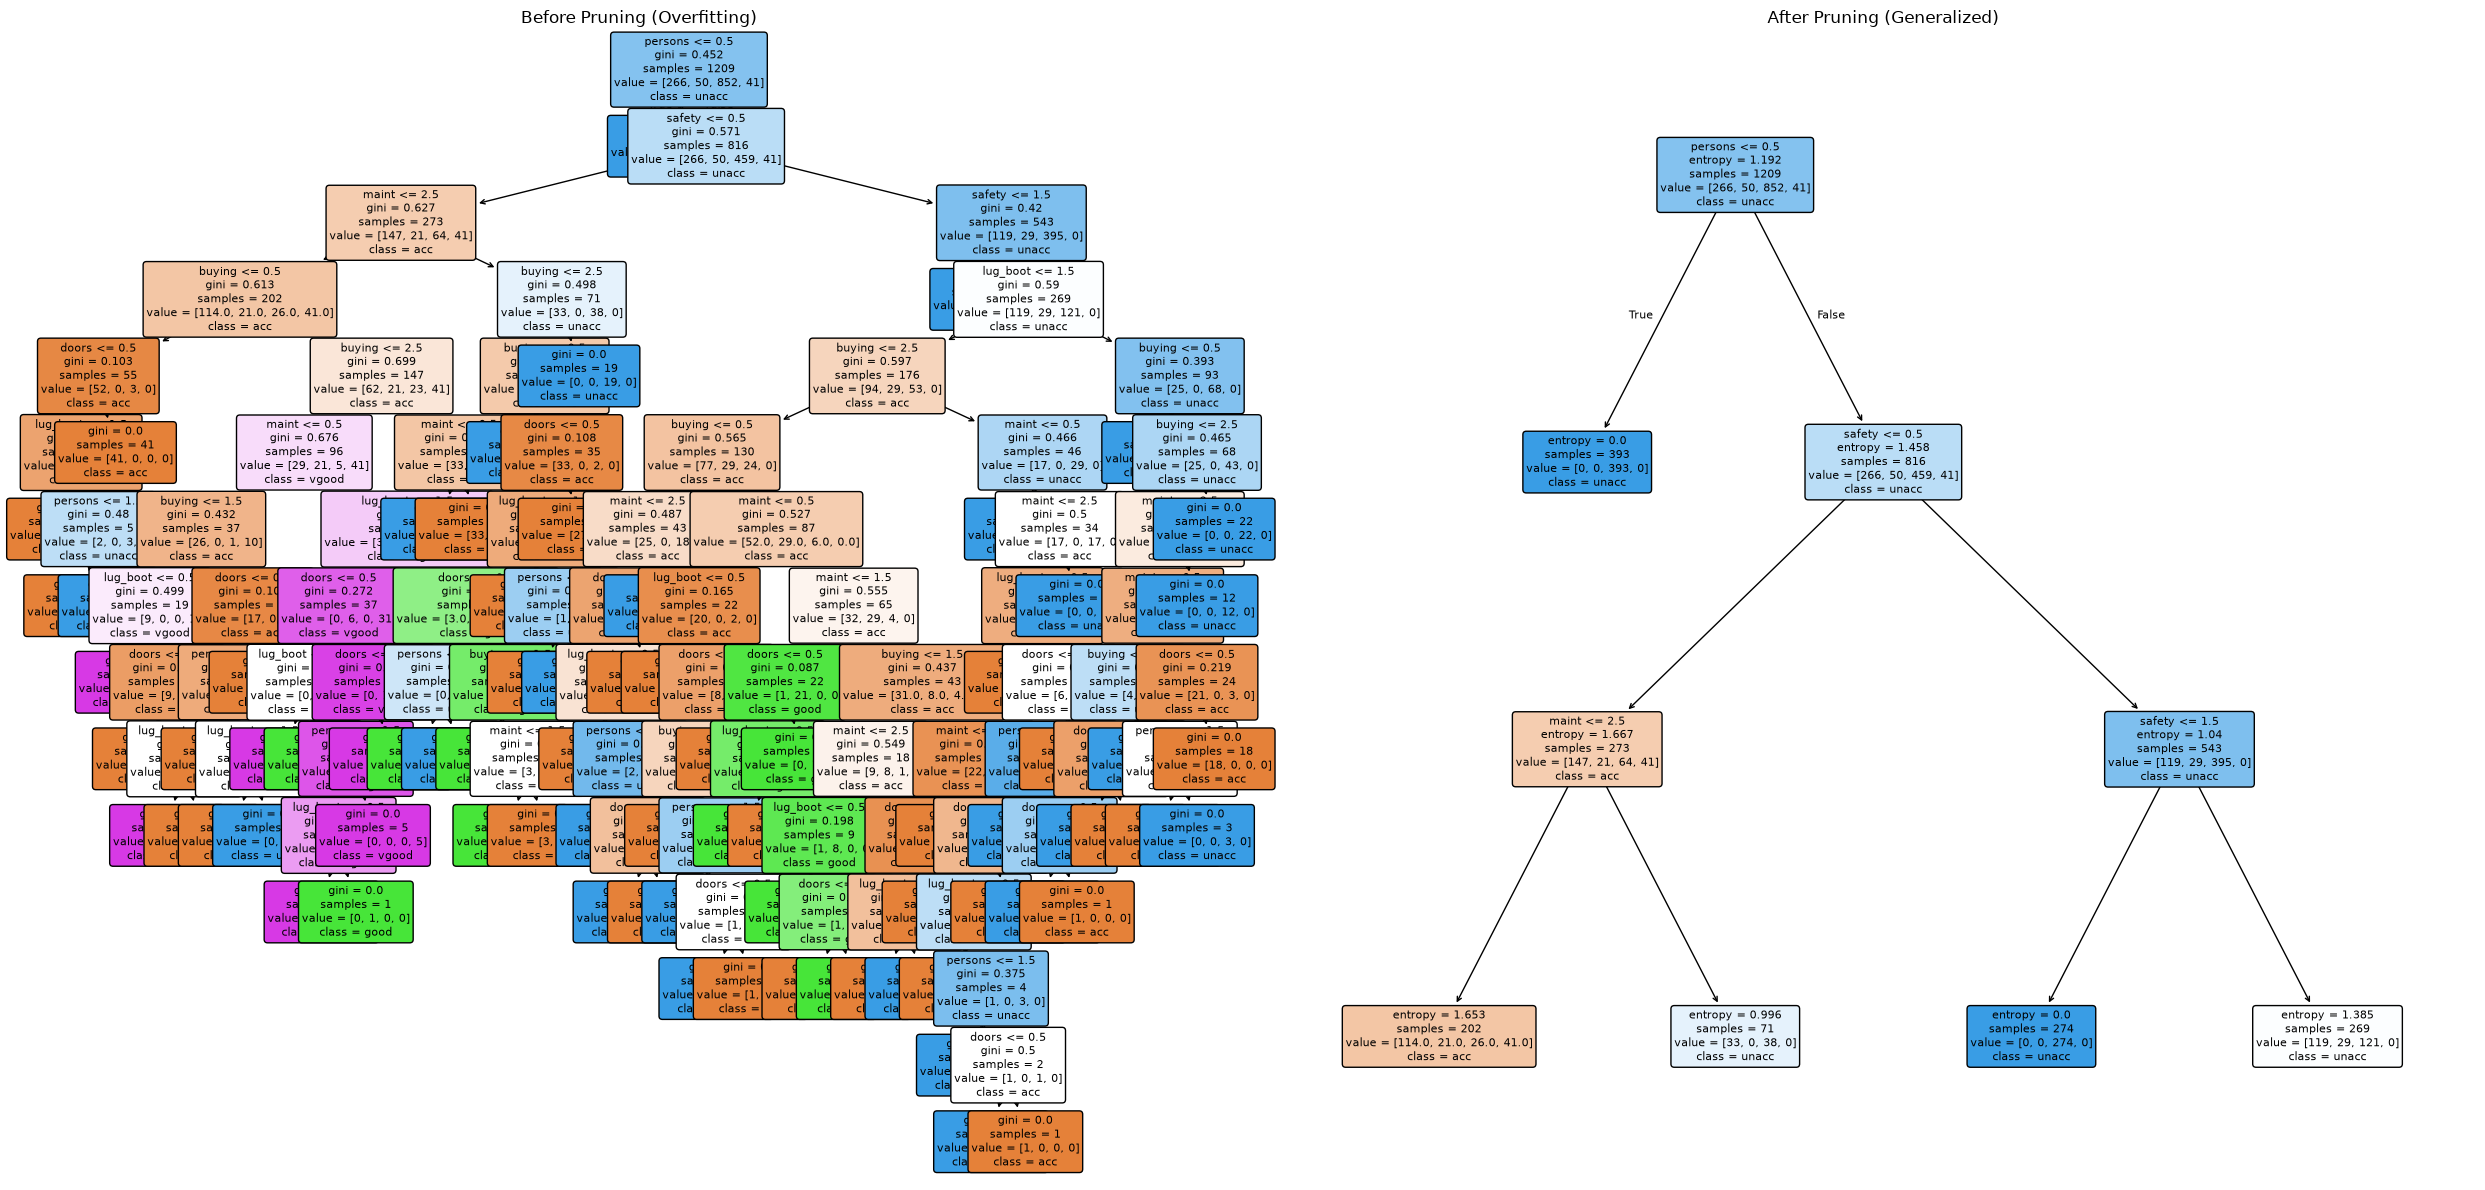

In [34]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import OrdinalEncoder, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score

# Features and Target
X = df.drop("class", axis=1)
y = df["class"]

# Save feature names (for plotting)
feature_names = X.columns


# Encode Features
oe = OrdinalEncoder()
X = oe.fit_transform(X)


# Encode Target
le = LabelEncoder()
y = le.fit_transform(y)


# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)


# Unpruned Model
unpruned_clf = DecisionTreeClassifier(random_state=42)

unpruned_clf.fit(X_train, y_train)


# Pruned Model
pruned_clf = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=3,
    random_state=42
)

pruned_clf.fit(X_train, y_train)


# Accuracy
unpruned_train_acc = accuracy_score(y_train,unpruned_clf.predict(X_train))
unpruned_test_acc = accuracy_score(y_test,unpruned_clf.predict(X_test))

pruned_train_acc = accuracy_score(y_train,pruned_clf.predict(X_train))
pruned_test_acc = accuracy_score(y_test,pruned_clf.predict(X_test))

print("------ Unpruned Model ------")
print(f"Train Accuracy : {unpruned_train_acc:.2f}")
print(f"Test Accuracy  : {unpruned_test_acc:.2f}")

print("\n------ Pruned Model ------")
print(f"Train Accuracy : {pruned_train_acc:.2f}")
print(f"Test Accuracy  : {pruned_test_acc:.2f}")


# Plot Decision Trees
fig, ax = plt.subplots(1, 2, figsize=(25, 12))

# Unpruned Tree
plot_tree(
    unpruned_clf,
    feature_names=feature_names,
    class_names=le.classes_,
    filled=True,
    rounded=True,
    fontsize=8,
    ax=ax[0]
)

ax[0].set_title("Before Pruning (Overfitting)")

# Pruned Tree
plot_tree(
    pruned_clf,
    feature_names=feature_names,
    class_names=le.classes_,
    filled=True,
    rounded=True,
    fontsize=8,
    ax=ax[1]
)

ax[1].set_title("After Pruning (Generalized)")

plt.tight_layout()
plt.show()